# Lineær Regresjon i scikit-learn

*Scikit-learn* (`sklearn`) er eit populært bibliotek både for maskinlæring og
konvensjonell statistikk.  Mange populære datasett er inkludert
i biblioteket, til testing og utprøving, og her skal me bruka eitt 
av dei, nemleg eit for prediksjon av utvikling av diabetes.
Detaljane står i 
[dokumentasjonen på datasettet](https://scikit-learn.org/stable/datasets/toy_dataset.html#diabetes-dataset).


::: {hint}
Når me finn datasett skal me vera merksame på kvar dei kjem frå og
med kva hensikt dei er gjort tilgjengeleg.  Data i dette kurset kan
me grovt dela i vitskaplege og teknologiske data.

Vitskaplege data er empiriske data som er samla og røkta for å la
oss seia noko om røynda.
[Statistisk Sentralbyrå](https://www.ssb.no/) og
[EuroStat](https://ec.europa.eu/eurostat) publiserer slike data.
Ein kan òg få børsdata, men dei er ikkje alltid gratis.

Teknologiske data er røkta for å testa maskinlæringsmodellar,
statistiske metodar og programvare. Slike data kan vera empiriske,
men dei kan òg vera syntetisk generert for å likna empiriske datasett.
Det kan vera viktig når empiriske data er sensitive.
Empiriske datasett kan òg vera forenkla for å vera enklare å bruka og
for å testa spesifikke teknikkar.

I denne øvinga bruker me eit slikt teknologisk datasett.
Andre populære kjelder til slike datasett er
[Kaggle](https://www.kaggle.com/) og [UC Irvine](https://archive.ics.uci.edu/).
:::

## Rettleidd læring

Den teknikken som me skal bruka her er kjend i maskinlæring som
rettleidd læring eller *supevised learning*.
Me har eit datasett der kvart individ eller objekt har nokre eigenskapar $x$
som er enkle å observera og nokre eigenskapar $y$ som er vanskelegare.
Me ynskjer å laga ein *prediksjonsmodell* som let oss predikera $y$ ved
hjelp av $x$.

I rettleidd læring føreset me eit datasett der både $x$ og $y$ er kjende
for ei rekkje individ. 
Merk at både $x$ og $y$ kan innehalda éin eller fleire variablar.

::: {admonition} Definisjon
Ein **modell** i maskinlæring og statistikk er ein matematisk funksjon
$M(x) = y$.  Når me reknar ut $M(x)$ seier me gjerne at me predikerer $y$.

Når me **trener** ein modell bruker me eit datasett med mange par $(x,y)$
til å tilpassa koeffisientane (ofte kalt *vektene*) i modellen, slik
at prediksjonane vert best mogleg.

Når me **testar** modellen bruker me òg eit datasett med par$(x,y)$.
For kvar $x$ finn me $\hat y=M(x)$ og samanliknar prediksjonen $\hat y$
med den sanne verdien $y$ for å sjå kor god prediksjonen er.
:::

I *praktisk bruk* observerer me berre $x$, og den einaste måten me kan
finna $y$ på, er å bruka prediksjonen $\hat y=M(x)$ frå modellen i
staden.

For å få ein påliteleg test av modellen, er det viktig at testdatasettet
er uavhengig av treningsdatasettet.  Ein modell som gjer det godt på
treningssettet treng ikkje generalisera til andre data.

Desse prinsippa er dei same for klassiske teknikkar som lineær regresjon
og for nevrale nettverk og andre moderne maskinlæringsalgoritmar.
Biblioteket `sklearn` er generisk og støtter heile spekteret av modellar.
I denne øvinga bruker me lineær regresjon.

## Datasettet

For å lasta datasettet importerer me `sklearn` og bruker biblioteket.
Datasettet som me vil bruka er publisert som ein del av `sklearn` for
testformål.

In [1]:
from sklearn.datasets import load_diabetes
diabetes = load_diabetes()
display(diabetes)

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]], shape=(442, 10)),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142.

::: {admonition} Oppgåve
Kva datatype er `diabetes`?
:::

::: {admonition} Refleksjon
Kva delar av `diabetes`-objektet er interessante for analyse?
:::

Dette datasettet er førebudd spesielt for testing av regresjonsmodellar.
Difor skil det mellom *input* eller `data`, og den variabelen som ein
skal freista å predikera, *target*.

In [2]:
print(diabetes.data.shape)
print(diabetes.target.shape)

(442, 10)
(442,)


Det er alltid nyttig å sjå på dimensjonane på datasett.
Her har med 442 rader, same for `data` og `target`.
Der er ti inn-variablar i `data` og éin ut-variabel i `target`.
Om me ser på eit par liner i toppen av kvar matrise, ser me at alt
er tal.

In [3]:
print(diabetes.target[:3])
print(diabetes.data[:3,:])

[151.  75. 141.]
[[ 0.03807591  0.05068012  0.06169621  0.02187239 -0.0442235  -0.03482076
  -0.04340085 -0.00259226  0.01990749 -0.01764613]
 [-0.00188202 -0.04464164 -0.05147406 -0.02632753 -0.00844872 -0.01916334
   0.07441156 -0.03949338 -0.06833155 -0.09220405]
 [ 0.08529891  0.05068012  0.04445121 -0.00567042 -0.04559945 -0.03419447
  -0.03235593 -0.00259226  0.00286131 -0.02593034]]


::: {hint}
Datatypen åt `diabetes.data` og `diabetes.target` er `numpy` *array*.
Sjå [numpy](./numpy.ipynb)-øvinga for meir informasjon.
:::

::: {admonition} Merknad
Datasettet er skalert og normalisert.  Det har ein del føremonar for
algoritmane, men for å kunne tolka data må me då finna ut korleis
dei er skalert for å konvertera dei til kjende einingar.  
Det kan vera at ein kan finna denne informasjonen i dokumentasjonen
og andre kjelder som har utvikla datasettet, men det tek me oss ikkje
tid til.
:::

## Visualisering med spreidingsplott

::: {admonition} Oppgåve
Datastrukturen `diabetes` inneheld og ei beskriving, som `diabetes.DESCR`.
For å sjå beskrivinga, er det best å bruka `print` eller `display`.

Kva tyder dei ulike søylene?
:::


Normalt bruker ein fleire *input*-variablar i modellen, men for å
kunna visualisera han pent i 2D, skal me berre bruke éin.
T.d. kan me ta ut den tredje søyla.

In [4]:
import numpy as np
x = diabetes.data[:,2:3]
print(x.shape)
y = diabetes.target
print(y.shape)

(442, 1)
(442,)


::: {admonition} Oppgåve
Kva er skilnaden på `diabetes.data[:,2:3]` og `diabetes.data[:,2]`?  
Du kan sjekka ved å endra på koden?
:::

Merk at `x` må vera ei to-dimensjonal matrise når me går vidare,
sjølv om ho berre har éi søyle.

Før me går vidare, er det greitt å visualisera, so me ser kva
me arbeider med.

[Text(0.5, 0, '$x$'), Text(0, 0.5, '$y$')]

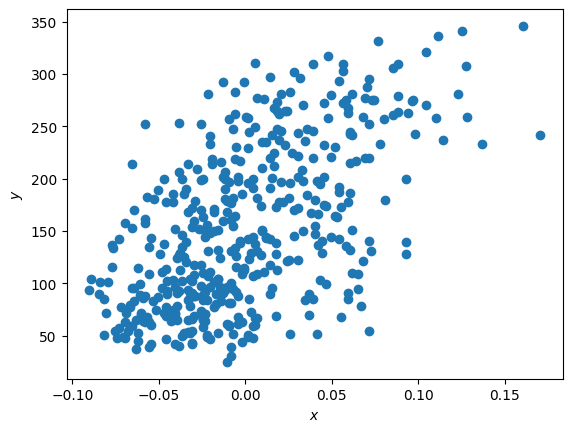

In [5]:
import matplotlib.pyplot as plt

ax = plt.subplot()
scatter = ax.scatter( x, y )
ax.set(xlabel="$x$", ylabel="$y$")

::: {admonition} Refleksjon
Kva fortel plottet deg?

Variablane her er hhv. BMI ($x$) og sjukdomsutvikling ($y$).
Er der samanheng mellom dei to?  Trur du BMI er ein god predikator
aleine?
:::

::: {admonition} Merknad
I aksenamna brukte me notasjonen `$x$` og `$y$`.  
Det er $\LaTeX$-notasjon som gjerne kan brukast til
matematiske symbol både i matplotlib og markdown.
:::

## Prediksjonsmodell

Det fyrste me må gjera i `sklearn` er å instantiera ein modell.

In [6]:
from sklearn import linear_model
reg = linear_model.LinearRegression()

Desse kodelinene lagar ein lineær regresjonsmodell, men me har ikkje
tilpassa vektene, so modellen representerer ingenting og evt. 
prediksjonar vil vera vilårlege.
For å tilpassa vektene til datasettet vårt, bruker me `fit()`-metoden.

In [7]:
reg.fit(x,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


No har me ein modell av datasettet, og alt er klart for å gjera
prediksjonar.
Lat oss sjå for oss at me observerer ein person med $x=0{,}1$. 
Me kan predikera $y$ slik.

In [8]:
print( reg.predict([[0.1]]) )

[247.0770102]


::: {admonition} Refleksjon
Samanlikna denne prediksjonen med spreidingsplottet over.
Verker prediksjonen sannsynleg?
:::

::: {admonition} Merknad
Innparametern til `predict` er ein 2D-struktur, anten ein numpy-*array* eller her 
ei liste av lister.  Grunnen er at `predict` kan predikare for mange $x$-verdiar
(rader) samstundes, i tillegg til at der vanligvis er fleire inn-variablar
(søyler).
:::

Me kan plotta prediksjonsmodellen ved å predikera nokre verdier.
Me kan predikera for fleire $x$-verdiar vha. listekomprehensjon, slik vi har gjort før.
Det kan se slik ut:

In [9]:
xv = [ -0.1, 0, 0.1, 0.15 ]
yv = [ reg.predict([[x]]) for x in xv ]
print( xv )
print( yv )

[-0.1, 0, 0.1, 0.15]
[array([57.18995812]), array([152.13348416]), array([247.0770102]), array([294.54877322])]


Det er derimot meir effektivt å gje `predict()`-metoden alle $x$-verdiane samla.
Det kan me få til med *numpy arrays*, men det er litt tricky.
Kvar $x$-verdi må vera ein *rad* i *array*en.  Dvs. me må ha ein 2D-*array* med éi søyle.
Om modellen hadde teke fleire variablar inn, ville me hatt fleire søyler.
Dette får me til slik.

In [10]:
xv = np.array( [ xv ] ).T
yv = reg.predict( xv )
print( xv )
print( yv )

[[-0.1 ]
 [ 0.  ]
 [ 0.1 ]
 [ 0.15]]
[ 57.18995812 152.13348416 247.0770102  294.54877322]


Den fyrste lina krev forklaring.  Me lagar fyrst ein 2D-*array* frå ei liste av lister.
Her er `xv` ei liste, og `[ xv ]` ei liste som inneheld ei liste, som vert éin rad i *array*en.
Deretter transponerer me matrisa med `.T`-operatoren, slik at den eine raden vert ei søyle.
No har med `xv` og `yv` som me kan plotta som fylgjer.
Det speler inga rolle for `plot()` at det eine er ein søylevektor og det andre ein rekkjevektor.

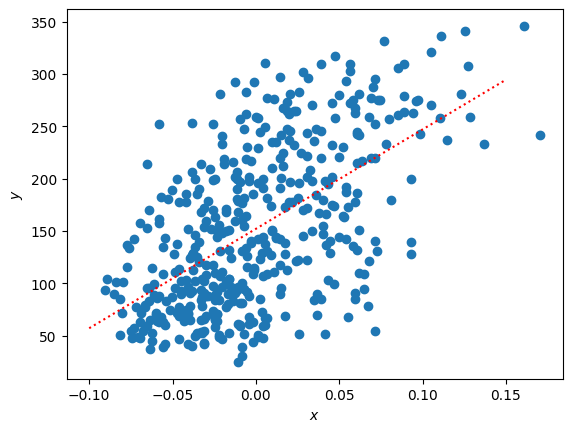

In [11]:
ax = plt.subplot()
scatter = ax.scatter( x, y )
ax.set(xlabel="$x$", ylabel="$y$")
ax.plot( xv, yv, "r:" )

::: {admonition} Refleksjon
Er prediksjonsmodellen ein rimeleg modell av datasettet?
:::

## Under panseret

For dei som kjenner matematikken i lineær regresjon er det nyttig å ta
ein titt under panseret.
Den lineære regresjonsmodellen er likninga
$$\hat y = ax + b.$$
Det er altso dei to koeffisientane $a$ og $b$ som vert bestemte
av `fit()`-metoden.
Me kan lesa desse koeffisientane ut av modellen.

In [12]:
print(reg.coef_)
print(reg.intercept_)

[949.43526038]
152.13348416289617


Konstantleddet $b$ vert kalt *intercept*, medan stigningstalet $a$ er
den eigentlege koeffisienten.
Koeffisienten er ei matrise fordi ein lineær modell treng éi vekt per *input*-variabel.
Vanligvis vil matrisa ha meir enn eitt element.
Me kan definera regresjonslikninga $f(x) = ax+b$ som ein python-funksjon, slik:

In [13]:
a = reg.coef_.flatten()[0]
b = reg.intercept_
def f(x): return a*x + b

Me har brukt `flatten()` for å flata ut matrisa og henta det eine elementet ho
inneheldt.

I teoren skal denne funksjonen `f()` gjera akkurat det same som `reg.predict()`.

::: {admonition} Oppgåve
Lag eit plott som samanliknar prediksjonane frå `f` og `reg.predict`.
Er dei alltid like?
:::


## Oppsummering

Læringsmålet i denne øvinga har vore å sjå ein mogleg syntaks
for lineær regresjon i python.

Me har vald scikit-learn her fordi det er eit utbreidd val for
trening og testing av maskinlæringsmodellar, og ein kan bruka
mange ulike algoritmar i det same rammeverket og med den same
syntaksen.

Det er ikkje det beste valet for statistikk, der ein gjerne
vil analysera dei einskilde parametrane i modellen.
Då kan ein anten sjå etter andre bibliotek, eller implementera
dei matematiske formlane sjølv.

Dømet er basert på ein post frå
[Medium](https://medium.com/@heyamit10/how-to-perform-linear-regression-using-pandas-scikit-learn-9fcfa6085fb0)

I neste øving ser me på [Evaluering for regresjon](Evaluering%20for%20regresjon).

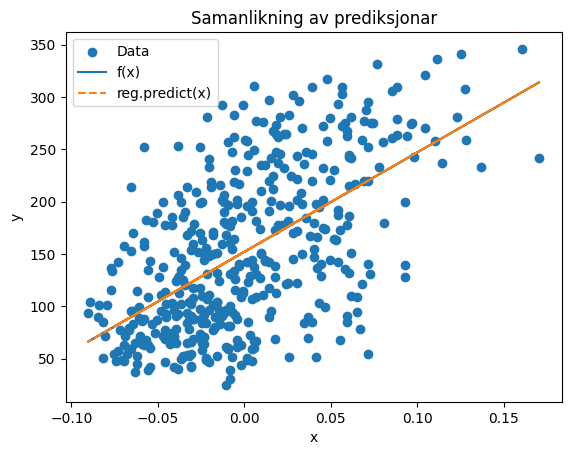

Are they always equal?  False
the error array is:  [[  0.         107.44784264  16.37300459 ...  73.67852066  21.48956853
  127.91409838]
 [107.44784264   0.          91.07483804 ...  33.76932197  85.95827411
   20.46625574]
 [ 16.37300459  91.07483804   0.         ...  57.30551607   5.11656394
  111.54109378]
 ...
 [ 73.67852066  33.76932197  57.30551607 ...   0.          52.18895214
   54.23557771]
 [ 21.48956853  85.95827411   5.11656394 ...  52.18895214   0.
  106.42452985]
 [127.91409838  20.46625574 111.54109378 ...  54.23557771 106.42452985
    0.        ]] 
 the max error is:  247.6416944564388


In [36]:
y_hat_f = f(x)
y_hat_reg = reg.predict(x)

plt.figure()
plt.scatter(x, y, label="Data")
plt.plot(x, y_hat_f, label="f(x)")
plt.plot(x, y_hat_reg, linestyle="--", label="reg.predict(x)")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Samanlikning av prediksjonar")
plt.show()


always_equal= np.allclose(y_hat_f, y_hat_reg)
print("Are they always equal? ", always_equal)

if not always_equal:
    error = np.abs(y_hat_f - y_hat_reg)
    max_error = np.max(error)
    print("the error array is: ", error, "\n", "the max error is: ", max_error)